# Comment marche la mesure de la RAM — et où vit quoi, par modèle

> Notebook pédagogique (présentation). Explique **le mécanisme** de mesure de la RAM
> sur NUCLEO-F439ZI, **où vit chaque partie de chaque modèle** (statique vs non constante,
> Flash vs RAM), et donne un **exemple concret chiffré sur le dataset Monitoring**
> couvrant *toute* la RAM (modèle + inférence + entraînement).
>
> Sources de vérité : tailles `.bss` lues de l'ELF (`arm-none-eabi-nm`), split
> statique/non constante calculé par [`scripts/ram_breakdown.py`](../../../scripts/ram_breakdown.py)
> et vérifié contre nm. Réf. technique : [`docs/context/ram_measurement.md`](../../../docs/context/ram_measurement.md).

In [1]:
import sys, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Racine projet
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

from scripts import ram_breakdown as rb
from measure_stack_watermark import read_symbols

ELF = rb.DEFAULT_ELF
FIGDIR = ROOT / "docs" / "figures" / "ram_measurement"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Symboles linker (plan mémoire réel)
SYM = read_symbols(ELF, ["_sdata", "_edata", "_sbss", "_ebss", "_estack"])
DATA = SYM["_edata"] - SYM["_sdata"]
BSS  = SYM["_ebss"] - SYM["_sbss"]
STACK_FREE = SYM["_estack"] - SYM["_ebss"]
RAM_TOTAL = 256 * 1024
print(f"ROOT={ROOT}")
print(f".data={DATA} B  .bss={BSS} B  zone pile libre={STACK_FREE} B")
print(f"_sbss=0x{SYM['_sbss']:08x}  _ebss=0x{SYM['_ebss']:08x}  _estack=0x{SYM['_estack']:08x}")

# Palette
C_STATIC  = "#4C72B0"   # bleu : statique (poids figés)
C_MODULAR = "#DD8452"   # orange : non constante (état CL mis à jour)
C_STACK   = "#55A868"   # vert : pile transitoire
C_DATA    = "#C44E52"   # rouge : .data
C_FREE    = "#E0E0E0"   # gris : libre

ROOT=/home/leonard/Documents/ENAC/cl-embedded
.data=460 B  .bss=105036 B  zone pile libre=91112 B
_sbss=0x200001cc  _ebss=0x20019c18  _estack=0x20030000


## 1. Le mécanisme de mesure

La RAM (192 Ko utiles, `0x20000000`→`0x20030000`) est découpée par l'éditeur de liens en
sections **contiguës** : `.data` (globales initialisées) puis `.bss` (globales à zéro, dont
les modèles), puis la **zone de pile libre** où la pile croît vers le bas depuis `_estack`.

Deux idées clés :
1. **`.bss` = `_ebss − _sbss`** est lu de 3 outils indépendants (voir §2) — pas une estimation.
2. **`.bss` n'inclut pas la pile.** Le pic réel = `.data + .bss + pic_de_pile`, le pic de pile
   étant mesuré par *stack painting* (§ figure ci-dessous).

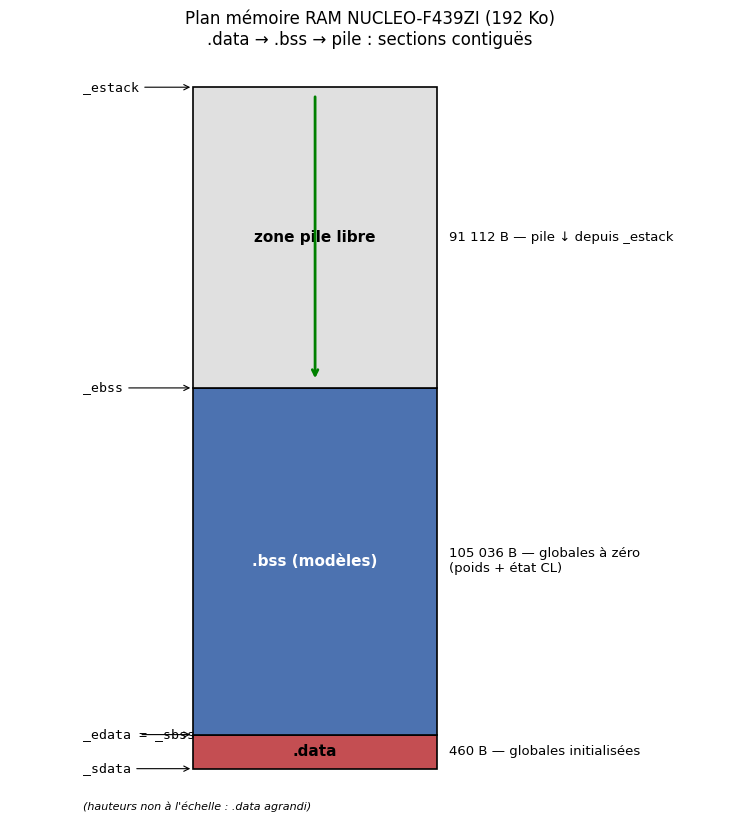

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_memory_map.png


In [2]:
# ── Schéma 1 : plan mémoire RAM (hauteurs non strictement à l'échelle) ──────
fig, ax = plt.subplots(figsize=(7.5, 8.5))
# .data (460 B) est négligeable en proportion → hauteur plancher pour rester lisible.
H_DATA_MIN = 0.05
h_data = H_DATA_MIN
rem = 1.0 - h_data
h_bss = rem * BSS / (BSS + STACK_FREE)
h_free = rem * STACK_FREE / (BSS + STACK_FREE)

def band(y0, h, color, label, txt_right):
    ax.add_patch(mpatches.Rectangle((0, y0), 1, h, facecolor=color, edgecolor="black", lw=1.2))
    ax.text(0.5, y0 + h/2, label, ha="center", va="center", fontsize=11, weight="bold",
            color="white" if color not in (C_FREE, C_DATA) else "black")
    ax.text(1.05, y0 + h/2, txt_right, ha="left", va="center", fontsize=9.5)

band(0, h_data, C_DATA, ".data", f"{DATA} B — globales initialisées")
band(h_data, h_bss, C_STATIC, ".bss (modèles)",
     f"{BSS:,} B — globales à zéro\n(poids + état CL)".replace(",", " "))
band(h_data+h_bss, h_free, C_FREE, "zone pile libre",
     f"{STACK_FREE:,} B — pile ↓ depuis _estack".replace(",", " "))

# bornes linker à gauche (décalées verticalement pour ne pas se chevaucher)
for y, name in [(0.0, "_sdata"), (h_data, "_edata = _sbss"),
                (h_data+h_bss, "_ebss"), (1.0, "_estack")]:
    ax.annotate(name, xy=(0, y), xytext=(-0.45, y), fontsize=9.5, va="center",
                family="monospace", arrowprops=dict(arrowstyle="->", lw=0.8))
ax.annotate("", xy=(0.5, h_data+h_bss+0.01), xytext=(0.5, 0.99),
            arrowprops=dict(arrowstyle="->", color="green", lw=2))
ax.text(-0.45, -0.06, "(hauteurs non à l'échelle : .data agrandi)", fontsize=8, style="italic")
ax.set_xlim(-0.75, 2.2); ax.set_ylim(-0.09, 1.05); ax.axis("off")
ax.set_title("Plan mémoire RAM NUCLEO-F439ZI (192 Ko)\n"
             ".data → .bss → pile : sections contiguës", fontsize=12)
plt.tight_layout(); plt.savefig(FIGDIR/"fig_memory_map.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_memory_map.png")

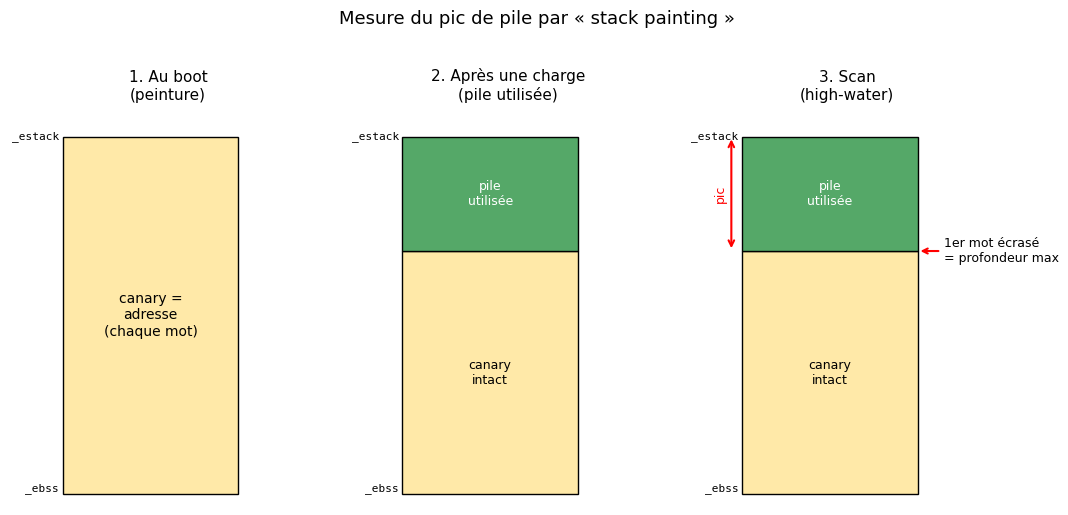

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_stack_painting.png


In [3]:
# ── Schéma 2 : stack painting (high-water mark) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharey=True)
titles = ["1. Au boot\n(peinture)", "2. Après une charge\n(pile utilisée)", "3. Scan\n(high-water)"]
# fractions illustratives
used = 0.32
for k, ax in enumerate(axes):
    # zone sentinelle (bas) + zone utilisée (haut)
    if k == 0:
        ax.add_patch(mpatches.Rectangle((0,0),1,1, facecolor="#FFE9A8", edgecolor="black"))
        ax.text(0.5,0.5,"canary =\nadresse\n(chaque mot)", ha="center", va="center", fontsize=10)
    else:
        ax.add_patch(mpatches.Rectangle((0,0),1,1-used, facecolor="#FFE9A8", edgecolor="black"))
        ax.add_patch(mpatches.Rectangle((0,1-used),1,used, facecolor=C_STACK, edgecolor="black"))
        ax.text(0.5,(1-used)/2,"canary\nintact", ha="center", va="center", fontsize=9)
        ax.text(0.5,1-used/2,"pile\nutilisée", ha="center", va="center", fontsize=9, color="white")
    if k == 2:
        ax.annotate("1er mot écrasé\n= profondeur max", xy=(1,1-used), xytext=(1.15,1-used),
                    fontsize=9, va="center",
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
        ax.annotate("", xy=(-0.06,1-used), xytext=(-0.06,1.0),
                    arrowprops=dict(arrowstyle="<->", color="red", lw=1.5))
        ax.text(-0.12,1-used/2,"pic", rotation=90, color="red", va="center", ha="center", fontsize=9)
    ax.text(-0.02,1.0,"_estack", ha="right", va="center", family="monospace", fontsize=8)
    ax.text(-0.02,0.0,"_ebss", ha="right", va="bottom", family="monospace", fontsize=8)
    ax.set_title(titles[k], fontsize=11); ax.set_xlim(-0.3,1.5); ax.set_ylim(-0.03,1.08); ax.axis("off")
fig.suptitle("Mesure du pic de pile par « stack painting »", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(FIGDIR/"fig_stack_painting.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_stack_painting.png")

## 2. Vérification : `.bss` est contigu, et le chiffre est exact

`_sbss` et `_ebss` bornent **une seule section de sortie** du linker (`.bss { *(.bss) … }`) :
une section de sortie est par construction un bloc d'adresses **contiguës**, rien ne s'y
intercale. On le **prouve** en croisant quatre outils indépendants — ils donnent le même octet.

In [4]:
# Croisement des 4 sources pour la taille .bss
FW = ROOT / "firmware" / "stm32f4_blink"
def sh(cmd): return subprocess.check_output(cmd, text=True, cwd=FW)

size_out = sh(["arm-none-eabi-size", str(ELF)])
bss_size = int(size_out.splitlines()[1].split()[2])           # colonne bss
objd = sh(["arm-none-eabi-objdump", "-h", str(ELF)])
# format objdump -h : "Idx Name Size VMA LMA FileOff Algn" → repérer le champ ".bss"
bss_objd = next(int(p[p.index(".bss")+1], 16)
                for p in (l.split() for l in objd.splitlines()) if ".bss" in p)
bss_linker = SYM["_ebss"] - SYM["_sbss"]
# .map via parse_map_file
sys.path.insert(0, str(ROOT/"scripts"))
from parse_map_file import parse_map_file
bss_map = parse_map_file(FW/"build"/"stm32f4_blink.map")["bss_bytes"]

tbl = pd.DataFrame({
    "source": ["arm-none-eabi-size", "objdump -h (.bss Size)", "_ebss − _sbss (linker)", ".map (parse_map_file)"],
    ".bss (octets)": [bss_size, bss_objd, bss_linker, bss_map],
})
print(tbl.to_string(index=False))
assert len({bss_size, bss_objd, bss_linker, bss_map}) == 1, "les 4 sources doivent coïncider"
print(f"\n✅ Les 4 sources concordent : .bss = {bss_linker:,} B — contiguïté et exactitude prouvées.".replace(",", " "))

                source  .bss (octets)
    arm-none-eabi-size         105036
objdump -h (.bss Size)         105036
_ebss − _sbss (linker)         105036
 .map (parse_map_file)         105036

✅ Les 4 sources concordent : .bss = 105 036 B — contiguïté et exactitude prouvées.


## 3. Où vit quoi, pour chaque modèle

Dans chaque modèle on distingue deux natures de mémoire, **toutes deux dans la même struct
pré-allouée en `.bss`** :

| Nature | Définition | Origine / stockage |
|---|---|---|
| **Statique** | poids figés après l'init | constantes en **Flash** (`model_weights*.h`) → **copie de travail en `.bss`** |
| **Non constante** | état de *continual learning* mis à jour à bord | **`.bss` in-place** (réécrit par le SGD/EMA/accumulation) |

La **pile** (tableaux temporaires du forward/update) n'est PAS dans `.bss` ; comptée à part.

In [5]:
bd = rb.monitoring_breakdown(ELF)
rows = []
for name, m in bd.items():
    rows.append({
        "modèle": name,
        "statique (poids)": m["static"],
        "non constante (état CL)": m["modular"],
        ".bss total (nm réel)": m["bss_real_nm"],
        "pile inférence": m["stack_infer"],
        "pile entraînement": m["stack_train"],
        "MAJ (fonction)": m["update_fn"],
    })
df = pd.DataFrame(rows).set_index("modèle")
print("Ce qui est statique vs non constante, et ce qui est mis à jour :\n")
for name, m in bd.items():
    print(f"• {name:<12} statique = {m['static_desc']}")
    print(f"  {'':<12} non constante = {m['modular_desc']}\n")
df

Ce qui est statique vs non constante, et ce qui est mis à jour :

• EWC          statique = poids w1/w2/w3 + biais (MLP 5→32→16→2)
               non constante = Fisher diag. + θ* de référence + λ (régularisation EWC)

• HDC          statique = projection aléatoire proj[1000][5] (fixée à l'init)
               non constante = mémoire associative am[2][1000] + buffer retrain + ring

• Mahalanobis  statique = matrice de précision Σ⁻¹[5][5] + seuil + alpha EMA
               non constante = vecteur moyenne mean[5] (mis à jour par EMA)

• TinyOL       statique = encodeur + décodeur (auto-encodeur gelé)
               non constante = tête OtO w_master/b_master (seule partie entraînée)



,statique (poids),non constante (état CL),.bss total (nm réel),pile inférence,pile entraînement,MAJ (fonction)
modèle,,,,,,
EWC,3016,5636,8652,200,400,ewc_sgd_step() / ewc_consolidate()
HDC,20000,8332,28332,4000,4300,hdc_update() / hdc_binarize()
Mahalanobis,108,20,128,40,40,maha_update() (EMA)
TinyOL,5716,96,5812,212,212,oto_int8_update() (BCE/SGD)


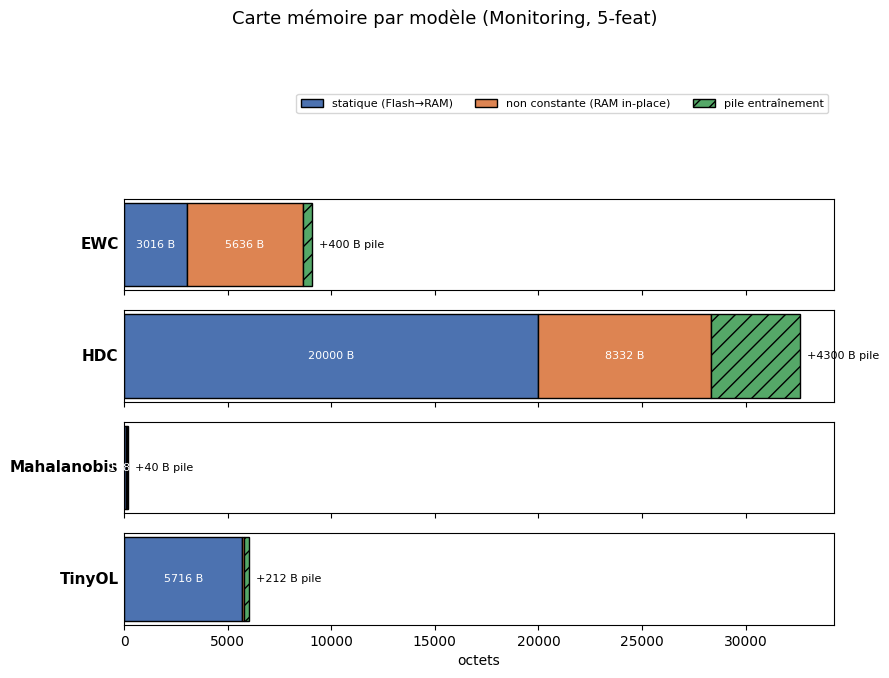

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_model_maps.png


In [6]:
# ── Schéma 3 : carte mémoire par modèle (barres empilées horizontales) ─────
fig, axes = plt.subplots(len(bd), 1, figsize=(9, 1.4*len(bd)+1), sharex=True)
for ax, (name, m) in zip(axes, bd.items()):
    s, mod, sinf, strain = m["static"], m["modular"], m["stack_infer"], m["stack_train"]
    ax.barh(0, s, color=C_STATIC, edgecolor="black", label="statique (Flash→RAM)")
    ax.barh(0, mod, left=s, color=C_MODULAR, edgecolor="black", label="non constante (RAM in-place)")
    ax.barh(0, strain, left=s+mod, color=C_STACK, edgecolor="black", hatch="//", label="pile entraînement")
    ax.set_yticks([]); ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=11, weight="bold")
    ax.text(s/2, 0, f"{s} B", ha="center", va="center", fontsize=8, color="white")
    if mod > 400: ax.text(s+mod/2, 0, f"{mod} B", ha="center", va="center", fontsize=8, color="white")
    ax.text(s+mod+strain, 0, f"  +{strain} B pile", ha="left", va="center", fontsize=8)
axes[0].legend(loc="upper right", fontsize=8, ncol=3, bbox_to_anchor=(1.0, 2.2))
axes[-1].set_xlabel("octets")
fig.suptitle("Carte mémoire par modèle (Monitoring, 5-feat)", y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig(FIGDIR/"fig_model_maps.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_model_maps.png")

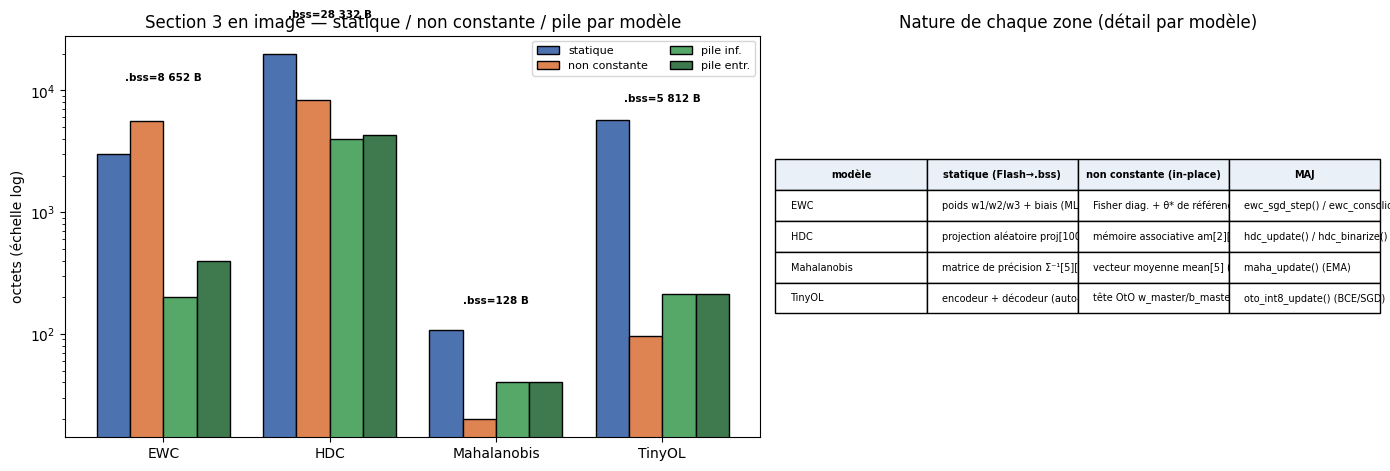

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_section3_detail.png


In [7]:
# ── Schéma 3bis : le tableau de la section 3, en image (détail par modèle) ──
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.8),
                               gridspec_kw={"width_ratios": [1.15, 1]})
names = list(bd.keys())
metrics = [("statique", "static", C_STATIC), ("non constante", "modular", C_MODULAR),
           ("pile inf.", "stack_infer", C_STACK), ("pile entr.", "stack_train", "#3E7A4E")]
x = np.arange(len(names)); w = 0.2
for j, (lab, key, col) in enumerate(metrics):
    axL.bar(x + (j - 1.5) * w, [bd[n][key] for n in names], w,
            color=col, edgecolor="black", label=lab)
axL.set_yscale("log"); axL.set_xticks(x); axL.set_xticklabels(names)
axL.set_ylabel("octets (échelle log)")
for i, n in enumerate(names):
    axL.text(i, bd[n]["bss_real_nm"] * 1.4,
             f".bss={bd[n]['bss_real_nm']:,} B".replace(",", " "),
             ha="center", fontsize=7.5, weight="bold")
axL.legend(fontsize=8, ncol=2, loc="upper right")
axL.set_title("Section 3 en image — statique / non constante / pile par modèle")

axR.axis("off")
rows = [[n, bd[n]["static_desc"][:36], bd[n]["modular_desc"][:36], bd[n]["update_fn"]]
        for n in names]
tbl = axR.table(cellText=rows,
                colLabels=["modèle", "statique (Flash→.bss)", "non constante (in-place)", "MAJ"],
                loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#EAF0F7"); cell.set_text_props(weight="bold")
axR.set_title("Nature de chaque zone (détail par modèle)")
plt.tight_layout(); plt.savefig(FIGDIR / "fig_section3_detail.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR / "fig_section3_detail.png")

## 4. Exemple concret sur Monitoring — toute la RAM

Tableau maître : pour chaque modèle, **tout ce qui influe sur la RAM** (poids statiques,
état CL non constant, `.data` partagé, pile en inférence et en entraînement), plus le **pic
total**. Le pic de pile carte réel est superposé s'il a été mesuré (`experiments/exp_S39_ram/`),
sinon marqué « à mesurer ».

In [8]:
import json
# Ingestion optionnelle des mesures carte
board = {}
bdir = ROOT / "experiments" / "exp_S39_ram"
if bdir.exists():
    for name, m in bd.items():
        f = bdir / f"ram_{m['symbols'][0].replace('g_','').split('_')[0]}.json"
        # nom simple par flag :
    for flag, name in {"ewc":"EWC","hdc":"HDC","mahalanobis":"Mahalanobis","tinyol":"TinyOL"}.items():
        f = bdir / f"ram_{flag}.json"
        if f.exists():
            board[name] = json.loads(f.read_text())

master = []
for name, m in bd.items():
    infer_total = DATA + m["bss_real_nm"] + m["stack_infer"]
    train_total = DATA + m["bss_real_nm"] + m["stack_train"]
    bp = board.get(name, {}).get("stack_peak_bytes")
    master.append({
        "modèle": name,
        "poids statique": m["static"],
        "état CL non constant": m["modular"],
        ".data partagé": DATA,
        ".bss modèle": m["bss_real_nm"],
        "pile inf. (analyt.)": m["stack_infer"],
        "pile entr. (analyt.)": m["stack_train"],
        "pic pile CARTE": bp if bp is not None else "à mesurer",
        "RAM pic entr. (analyt.)": train_total,
        "% de 256 Ko": round(100*train_total/RAM_TOTAL, 2),
    })
dfm = pd.DataFrame(master).set_index("modèle")
print("Exemple concret Monitoring — RAM complète (octets) :\n")
if not board:
    print("(pic carte non mesuré — lancer scripts/run_ram_board.py ; valeurs « à mesurer »)\n")
else:
    print("(pic carte = mesure réelle NUCLEO-F439ZI via stack painting)\n")
dfm

Exemple concret Monitoring — RAM complète (octets) :

(pic carte = mesure réelle NUCLEO-F439ZI via stack painting)



,poids statique,état CL non constant,.data partagé,.bss modèle,pile inf. (analyt.),pile entr. (analyt.),pic pile CARTE,RAM pic entr. (analyt.),% de 256 Ko
modèle,,,,,,,,,
EWC,3016,5636,460,8652,200,400,4712,9512,3.63
HDC,20000,8332,460,28332,4000,4300,4336,33092,12.62
Mahalanobis,108,20,460,128,40,40,4336,628,0.24
TinyOL,5716,96,460,5812,212,212,4336,6484,2.47


### Lecture importante : pile *logique par branche* vs pile *réelle mesurée*

Les colonnes « pile (analyt.) » donnent la taille des tableaux locaux **du chemin de code
de chaque modèle** (p.ex. HDC = `hv[HDC_DIM]` 4 Ko). Mais le **pic carte mesuré** est
**≈ identique (~4,3 Ko) pour tous les modèles**, avec EWC un peu au-dessus. Pourquoi ?

- Le compilateur alloue **une seule trame de pile pour `pipeline_run()`**, dimensionnée
  sur le **maximum de toutes ses branches** — donc la réservation de `hv[HDC_DIM]` (4 Ko,
  branche HDC) est présente **même quand on exécute EWC ou Mahalanobis**. C'est pourquoi le
  plancher est ~4,3 Ko partout.
- EWC en mode entraînement descend plus profond (appel `ewc_sgd_step`, ~+380 B) → 4 712 B.

**Conséquence honnête** : le pic de pile réel est une propriété du **firmware entier**
(~4,3–4,7 Ko), pas isolable proprement par modèle avec cette méthode. Le chiffre à retenir
pour Gap 2 est le **pic total mesuré ≈ 111 Ko** (`.data + .bss + pic_pile`), très en-dessous
des 256 Ko — et c'est une **mesure**, pas une estimation.

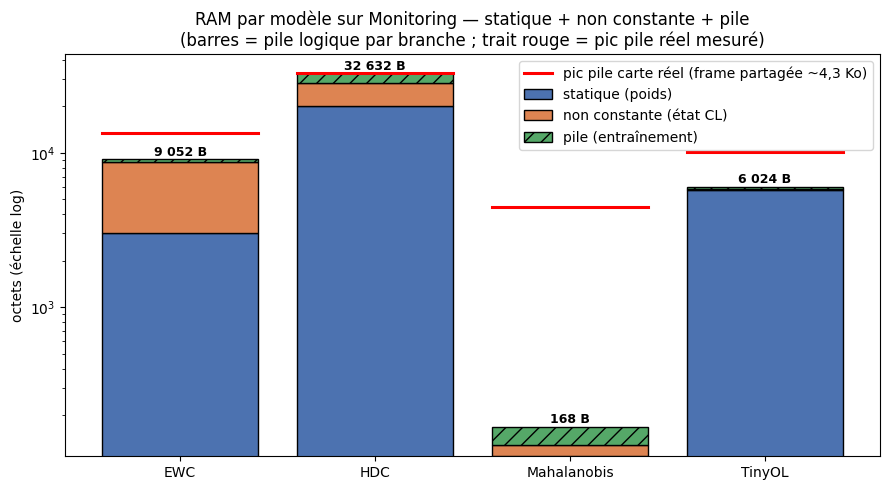

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_monitoring_stacked.png


In [9]:
# ── Schéma 4 : comparaison empilée des 4 modèles (échelle log) ─────────────
fig, ax = plt.subplots(figsize=(9, 5))
names = list(bd.keys())
statics = [bd[n]["static"] for n in names]
moduls  = [bd[n]["modular"] for n in names]
stacks  = [bd[n]["stack_train"] for n in names]
x = np.arange(len(names))
ax.bar(x, statics, color=C_STATIC, edgecolor="black", label="statique (poids)")
ax.bar(x, moduls, bottom=statics, color=C_MODULAR, edgecolor="black", label="non constante (état CL)")
ax.bar(x, stacks, bottom=np.array(statics)+np.array(moduls), color=C_STACK,
       edgecolor="black", hatch="//", label="pile (entraînement)")
for i, n in enumerate(names):
    tot = statics[i]+moduls[i]+stacks[i]
    ax.text(i, tot*1.05, f"{tot:,} B".replace(",", " "), ha="center", fontsize=9, weight="bold")
# Pic RAM réel mesuré carte (.bss modèle + pic pile mesuré) — marqueur rouge
if board:
    for i, n in enumerate(names):
        sp = board.get(n, {}).get("stack_peak_bytes")
        if sp is not None:
            real = bd[n]["bss_real_nm"] + sp
            ax.plot([i-0.4, i+0.4], [real, real], color="red", lw=2.2, zorder=5)
    ax.plot([], [], color="red", lw=2.2, label="pic pile carte réel (frame partagée ~4,3 Ko)")
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_yscale("log")
ax.set_ylabel("octets (échelle log)")
ax.set_title("RAM par modèle sur Monitoring — statique + non constante + pile\n"
             "(barres = pile logique par branche ; trait rouge = pic pile réel mesuré)")
ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR/"fig_monitoring_stacked.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_monitoring_stacked.png")

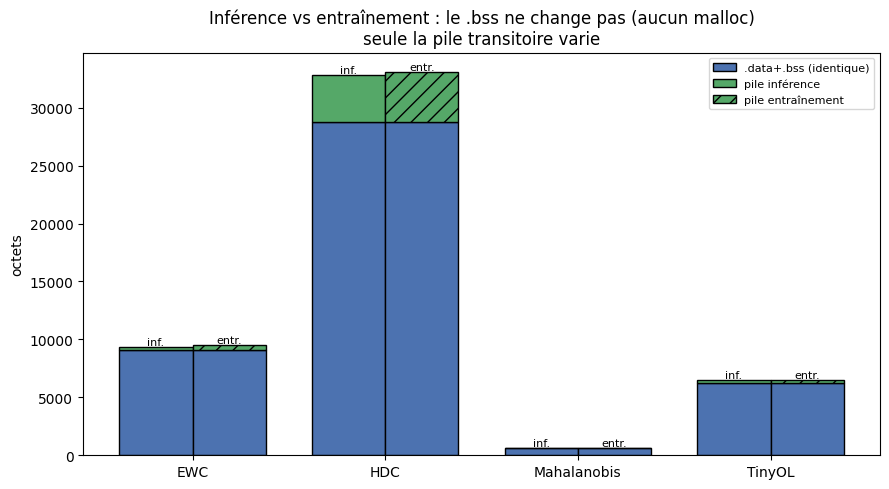

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_infer_vs_train.png


In [10]:
# ── Schéma 5 : inférence vs entraînement — .bss identique, seule la pile change
fig, ax = plt.subplots(figsize=(9, 5))
w = 0.38; x = np.arange(len(names))
bss_vals = [bd[n]["bss_real_nm"] + DATA for n in names]
inf_stack = [bd[n]["stack_infer"] for n in names]
tr_stack  = [bd[n]["stack_train"] for n in names]
ax.bar(x-w/2, bss_vals, w, color=C_STATIC, edgecolor="black", label=".data+.bss (identique)")
ax.bar(x-w/2, inf_stack, w, bottom=bss_vals, color=C_STACK, edgecolor="black", label="pile inférence")
ax.bar(x+w/2, bss_vals, w, color=C_STATIC, edgecolor="black")
ax.bar(x+w/2, tr_stack, w, bottom=bss_vals, color=C_STACK, hatch="//", edgecolor="black", label="pile entraînement")
for i in range(len(names)):
    ax.text(x[i]-w/2, bss_vals[i]+inf_stack[i], "inf.", ha="center", va="bottom", fontsize=8)
    ax.text(x[i]+w/2, bss_vals[i]+tr_stack[i], "entr.", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("octets")
ax.set_title("Inférence vs entraînement : le .bss ne change pas (aucun malloc)\nseule la pile transitoire varie")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR/"fig_infer_vs_train.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_infer_vs_train.png")

### Pourquoi le pic de pile est ~identique pour tous les modèles

Explication du fait que **EWC 4 712 B ≈ HDC/Maha/TinyOL 4 336 B** alors que Mahalanobis
n'utilise « logiquement » que ~40 B de pile. Le schéma ci-dessous illustre l'effet
**« trame unique de `pipeline_run()` »** : le compilateur réserve une seule trame,
dimensionnée sur le **maximum de toutes les branches** (donc `hv[HDC_DIM]` = 4 Ko), qui
est présente **quel que soit le modèle exécuté**.

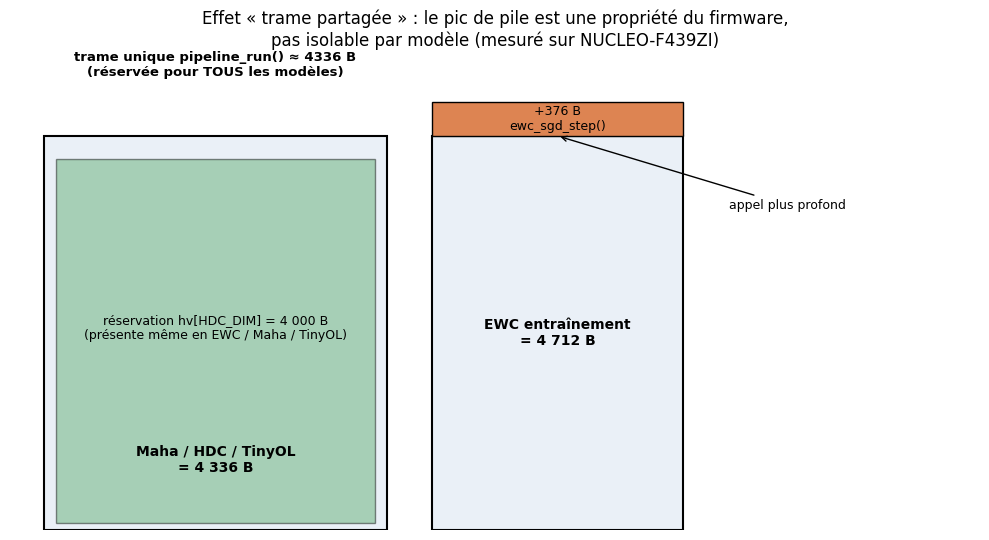

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_shared_frame.png


In [11]:
# ── Schéma 6 : trame partagée de pipeline_run() ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
# Une seule trame réservée = max des branches. hv[HDC_DIM]=4 Ko domine.
branch_locals = {"branche HDC : hv[HDC_DIM]": 4000,
                 "branche EWC : logits+... ": 200,
                 "branche Maha : maha_x": 40,
                 "branche TinyOL : emb+recon": 212}
frame = 4336  # trame mesurée (~max des branches + overhead d'appel)
# trame réservée
ax.add_patch(mpatches.Rectangle((0,0),3.0,frame, facecolor="#EAF0F7", edgecolor="black", lw=1.5))
ax.text(1.5, frame+780, f"trame unique pipeline_run() ≈ {frame} B\n(réservée pour TOUS les modèles)",
        ha="center", va="center", fontsize=9.5, weight="bold")
# la réservation hv occupe l'essentiel
ax.add_patch(mpatches.Rectangle((0.1,80),2.8,4000, facecolor=C_STACK, alpha=.45, edgecolor="black"))
ax.text(1.5, 2100, "réservation hv[HDC_DIM] = 4 000 B\n(présente même en EWC / Maha / TinyOL)",
        ha="center", fontsize=9)
# EWC : trame supplémentaire ewc_sgd_step
ax.add_patch(mpatches.Rectangle((3.4,0),2.2,frame, facecolor="#EAF0F7", edgecolor="black", lw=1.5))
ax.add_patch(mpatches.Rectangle((3.4,frame),2.2,376, facecolor=C_MODULAR, edgecolor="black"))
ax.text(4.5, frame+188, "+376 B\newc_sgd_step()", ha="center", va="center", fontsize=9)
ax.text(4.5, frame/2, "EWC entraînement\n= 4 712 B", ha="center", va="center", fontsize=10, weight="bold")
ax.text(1.5, frame/2-1400, "Maha / HDC / TinyOL\n= 4 336 B", ha="center", va="center",
        fontsize=10, weight="bold")
ax.annotate("appel plus profond", xy=(4.5, frame), xytext=(6.0, frame-800),
            fontsize=9, arrowprops=dict(arrowstyle="->"))
ax.set_xlim(-0.3, 8.2); ax.set_ylim(0, frame+900); ax.axis("off")
ax.set_title("Effet « trame partagée » : le pic de pile est une propriété du firmware,\n"
             "pas isolable par modèle (mesuré sur NUCLEO-F439ZI)", fontsize=12)
plt.tight_layout(); plt.savefig(FIGDIR/"fig_shared_frame.png", dpi=300, bbox_inches="tight")
plt.show(); print("→", FIGDIR/"fig_shared_frame.png")

## 4ter. Borne supérieure statique de pile (`-fstack-usage`)

Le pic de pile ci-dessus est *mesuré* : il dépend de la charge streamée. Pour être sûr
qu'aucun chemin d'appel plus profond n'a été manqué, on le confronte à une borne
**statique**, calculée sans exécuter la carte. Le firmware est compilé avec
`-fstack-usage` (GCC émet un `build/<unité>.su` par unité de compilation, **0 impact sur
le code généré** — `.text`/`.data`/`.bss` bit-identiques) et
[`scripts/stack_usage_report.py`](../../../scripts/stack_usage_report.py) somme une
**chaîne pire-cas déclarée** le long de la boucle chaude :

> `main` → `pipeline_run` (détient `hv[HDC_DIM]` = 4 Ko) → noyau modèle le plus profond.

Le firmware n'a **pas de récursion** et dispatche les modèles par `switch`/`if` (appels
**directs**, pas de pointeurs de fonction) → le graphe d'appels est court et connu, la
chaîne déclarée est fiable. C'est une **contre-vérification** (« ceinture + bretelles »),
pas une preuve formelle. On vérifie l'invariant **`borne statique ≥ pic mesuré`** ; le
plus gros cadre du binaire, `hdc_retrain` (4 344 B), est **éliminé par `--gc-sections`**
(jamais appelé) et n'entre donc pas dans la borne.


Chaîne pire-cas déclarée (main → pipeline_run → noyau modèle) :
  entrée                                              main                        48 B
  boucle pipeline                                     pipeline_run              4128 B
  noyau modèle (feuille la plus profonde appelée par pipeline_run)ewc_mc_sgd_step            560 B
                                                      BORNE STATIQUE            4736 B

Contre-vérification borne ≥ pic mesuré :
  EWC          pic mesuré   4712 B  ≤  borne 4736 B  ✅ (marge +24 B)
  HDC          pic mesuré   4336 B  ≤  borne 4736 B  ✅ (marge +400 B)
  Mahalanobis  pic mesuré   4336 B  ≤  borne 4736 B  ✅ (marge +400 B)
  TinyOL       pic mesuré   4336 B  ≤  borne 4736 B  ✅ (marge +400 B)


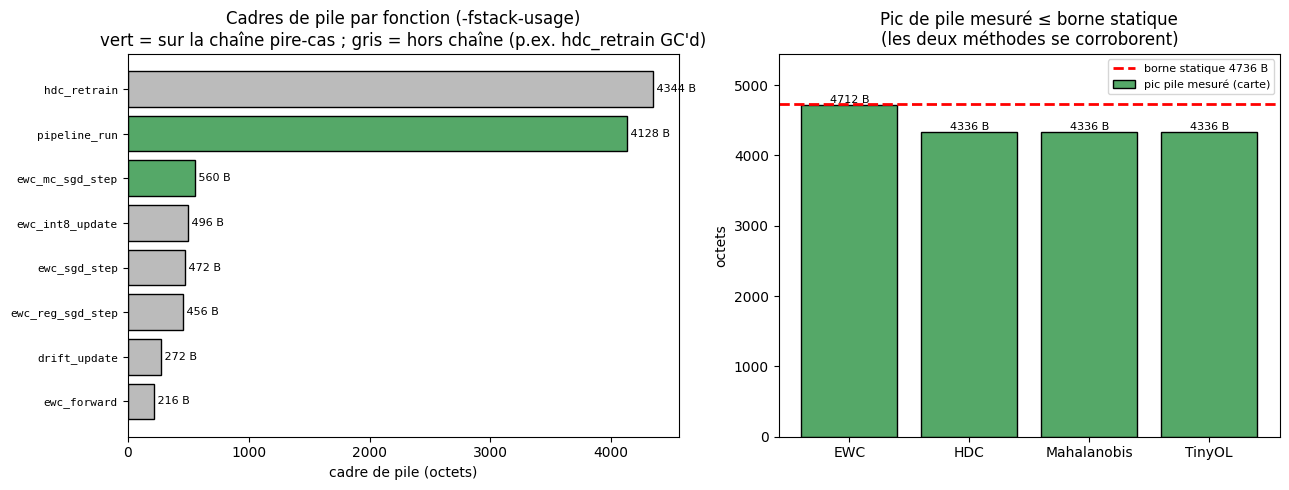


→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_stack_bound.png


In [12]:
# ── Borne statique -fstack-usage vs pic mesuré ─────────────────────────────
import stack_usage_report as su

frames = su.parse_su_files(su.DEFAULT_BUILD)          # build/*.su du firmware courant
res = su.compute_bound(frames)
BOUND = res["bound_bytes"]

print("Chaîne pire-cas déclarée (main → pipeline_run → noyau modèle) :")
for c in res["chain"]:
    print(f"  {c['level']:<52}{str(c['func']):<24}{c['frame']:>6} B")
print(f"  {'':<52}{'BORNE STATIQUE':<24}{BOUND:>6} B")

# Contre-vérification : borne ≥ pic mesuré, pour chaque modèle mesuré carte
print("\nContre-vérification borne ≥ pic mesuré :")
for name in bd:
    sp = board.get(name, {}).get("stack_peak_bytes")
    if sp is not None:
        ok = "✅" if BOUND >= sp else "❌"
        print(f"  {name:<12} pic mesuré {sp:>6} B  ≤  borne {BOUND} B  {ok} (marge {BOUND-sp:+d} B)")
        assert BOUND >= sp, f"borne statique < pic mesuré pour {name} !"

# ── Figure : cadres de pile + pic mesuré sous la borne ─────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.1, 1]})

# (gauche) plus gros cadres .su
top = sorted(frames, key=lambda f: f["frame"], reverse=True)[:8]
labels = [f["func"] for f in top][::-1]
vals = [f["frame"] for f in top][::-1]
cols = [C_STACK if f["func"] in {c["func"] for c in res["chain"]} else "#BBBBBB" for f in top][::-1]
axL.barh(range(len(vals)), vals, color=cols, edgecolor="black")
axL.set_yticks(range(len(vals))); axL.set_yticklabels(labels, fontsize=8, family="monospace")
for i, v in enumerate(vals):
    axL.text(v, i, f" {v} B", va="center", fontsize=8)
axL.set_xlabel("cadre de pile (octets)")
axL.set_title("Cadres de pile par fonction (-fstack-usage)\nvert = sur la chaîne pire-cas ; "
              "gris = hors chaîne (p.ex. hdc_retrain GC'd)")

# (droite) pic mesuré par modèle vs borne statique
names = list(bd.keys())
peaks = [board.get(n, {}).get("stack_peak_bytes", 0) for n in names]
axR.bar(range(len(names)), peaks, color=C_STACK, edgecolor="black", label="pic pile mesuré (carte)")
axR.axhline(BOUND, color="red", lw=2, ls="--", label=f"borne statique {BOUND} B")
for i, p in enumerate(peaks):
    if p: axR.text(i, p, f"{p} B", ha="center", va="bottom", fontsize=8)
axR.set_xticks(range(len(names))); axR.set_xticklabels(names)
axR.set_ylim(0, BOUND * 1.15); axR.set_ylabel("octets")
axR.set_title("Pic de pile mesuré ≤ borne statique\n(les deux méthodes se corroborent)")
axR.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR / "fig_stack_bound.png", dpi=300, bbox_inches="tight")
plt.show(); print("\n→", FIGDIR / "fig_stack_bound.png")

## 5. Pourquoi la mesure de la RAM est correcte — en une phrase chacune

- **Pas d'estimation pour `.bss`** : on lit la même valeur avec trois outils indépendants
  (`size`, `objdump`, le fichier `.map`) — au même octet près.
- **Contiguïté garantie** : `_sbss` et `_ebss` bornent une seule section de sortie du linker,
  contiguë par construction — rien ne peut s'intercaler entre les deux.
- **Aucun `malloc`** : toute la mémoire des modèles est **pré-allouée en `.bss`**, donc
  entièrement connue et mesurée **dès la compilation**.
- **L'entraînement en ligne n'ajoute pas de RAM permanente** : il réécrit des tableaux déjà
  comptés (Fisher, θ*, mémoire associative, moyenne EMA) ; il n'ajoute que de la **pile
  transitoire**, mesurée séparément par *high-water mark*.
- **Le pic total est une somme de termes tous mesurés** : `RAM_pic = .data + .bss + pic_pile`,
  aucun chiffre inventé.
- **Canary robuste** : la pile est peinte avec un motif **position-dépendant** (chaque mot
  = sa propre adresse), donc un buffer de pile rempli d'une constante répétée ne peut pas
  masquer une zone utilisée ; le risque résiduel (mot-frontière valant sa propre adresse)
  est ~1/2³², négligeable.
- **Bornée par le haut** : le pic de pile mesuré est corroboré par une **borne statique
  indépendante** (`-fstack-usage` + chaîne pire-cas déclarée) ; on vérifie
  `borne ≥ pic mesuré`, donc la mesure n'a pas pu manquer un chemin d'appel plus profond.

## 6. Cycle de vie mémoire par modèle (sur la carte)

Un schéma par modèle montre **les étapes d'exécution sur la carte** (Init → Forward → Loss →
Backprop → Update → Consolidation) et **quand se passe quelle mesure de RAM** :

- **① mesure `.bss` = à la COMPILATION** (`size`/`objdump`/`.map`) — c'est le **plancher
  permanent** : `.data` + `.bss statique` (poids figés, **lecture seule**, copiés de la Flash
  à l'init) + `.bss non constante` (état CL). Ce plancher **ne bouge jamais** pendant l'exécution.
- **② mesure du pic de pile = À L'EXÉCUTION** (*high-water mark*, carte) — la **pile
  transitoire** monte au forward, plus haut au backprop/update, puis **redescend à 0** au repos.
- **③ RAM totale instantanée (« cumulé » physique)** — 3ᵉ panneau : à chaque étape, on
  **empile** le plancher permanent (.data + statique + non constante, constant) et la pile de
  l'étape → c'est la RAM **réellement occupée à cet instant**. La seule variation d'une
  étape à l'autre est la pile ; le total au pic = `plancher + pile_max`.

> **Pourquoi PAS une somme cumulative (`cumsum`) des piles d'étape en étape ?** La pile est
> **libérée** entre les étapes (elle redescend à 0 — c'est le message de ②). Sommer les
> niveaux successifs compterait plusieurs fois de la mémoire déjà rendue et produirait un
> chiffre qui ne correspond à aucun octet réellement occupé. Le seul « cumulé » honnête est
> l'empilement **à un instant donné** : plancher + pile courante (panneau ③).

Le **statique** fait fonctionner le modèle : à l'init, les poids sont copiés Flash→`.bss`,
puis **lus en lecture seule à chaque forward** (ils ne sont jamais réalloués). L'état **non constant**
est réécrit **in-place** à chaque update (SGD/EMA/accumulation) — **taille constante, +0 B**
de RAM permanente. Seule la **pile** varie dans le temps.

> Les niveaux de pile tracés sont **analytiques par branche** (tableaux locaux du chemin du
> modèle) ; le **trait rouge** rappelle le **pic réel mesuré firmware-wide** (~4,3–4,7 Ko),
> dominé par la trame partagée `hv[HDC_DIM]` (cf. Schéma 6).

### Exemples entiers chiffrés (Monitoring 5-feat, octets réels)

- **EWC** — *Init* : 3 016 B poids (w1/w2/w3+biais) copiés en `.bss` + 5 636 B non constante
  (Fisher+θ*+λ). *Inférence* : forward MLP 5→32→16→2, pile ~200 B (h1+h2+logits), poids lus
  en lecture seule. *Update* : `ewc_sgd_step()` rétro-propage (pile ~400 B, +dout/dh2/dh1),
  réécrit les poids **in-place** ; `ewc_consolidate()` recalcule Fisher+θ* **in-place** en
  frontière de tâche. RAM permanente inchangée.
- **HDC** — *Init* : `proj[1000][5]` 20 000 B (projection aléatoire figée). *Inférence* :
  `hdc_encode` alloue `hv[1000]` = **4 000 B de pile**, puis `hdc_predict` (produit scalaire
  avec l'AM). *Update* : `hdc_update` **accumule** dans `am[2][1000]` (non constante, in-place) +
  push ring buffer ; `hdc_binarize` repasse l'AM en ±1 **in-place**.
- **Mahalanobis** — *Init* : `Σ⁻¹[5][5]` 108 B + seuil/alpha. *Inférence* : distance de
  Mahalanobis, pile ~40 B (diff+left). *Update* : `maha_update` met à jour `mean[5]` par EMA
  **in-place** (20 B). Pas de backprop ni de consolidation.
- **TinyOL** — *Init* : encodeur+décodeur gelés 5 716 B. *Inférence* : forward auto-encodeur,
  pile ~212 B (h1+emb+recon). *Update* : seule la tête OtO (96 B) est entraînée
  (`oto_int8_update`, BCE/SGD) **in-place** ; encodeur/décodeur restent figés.

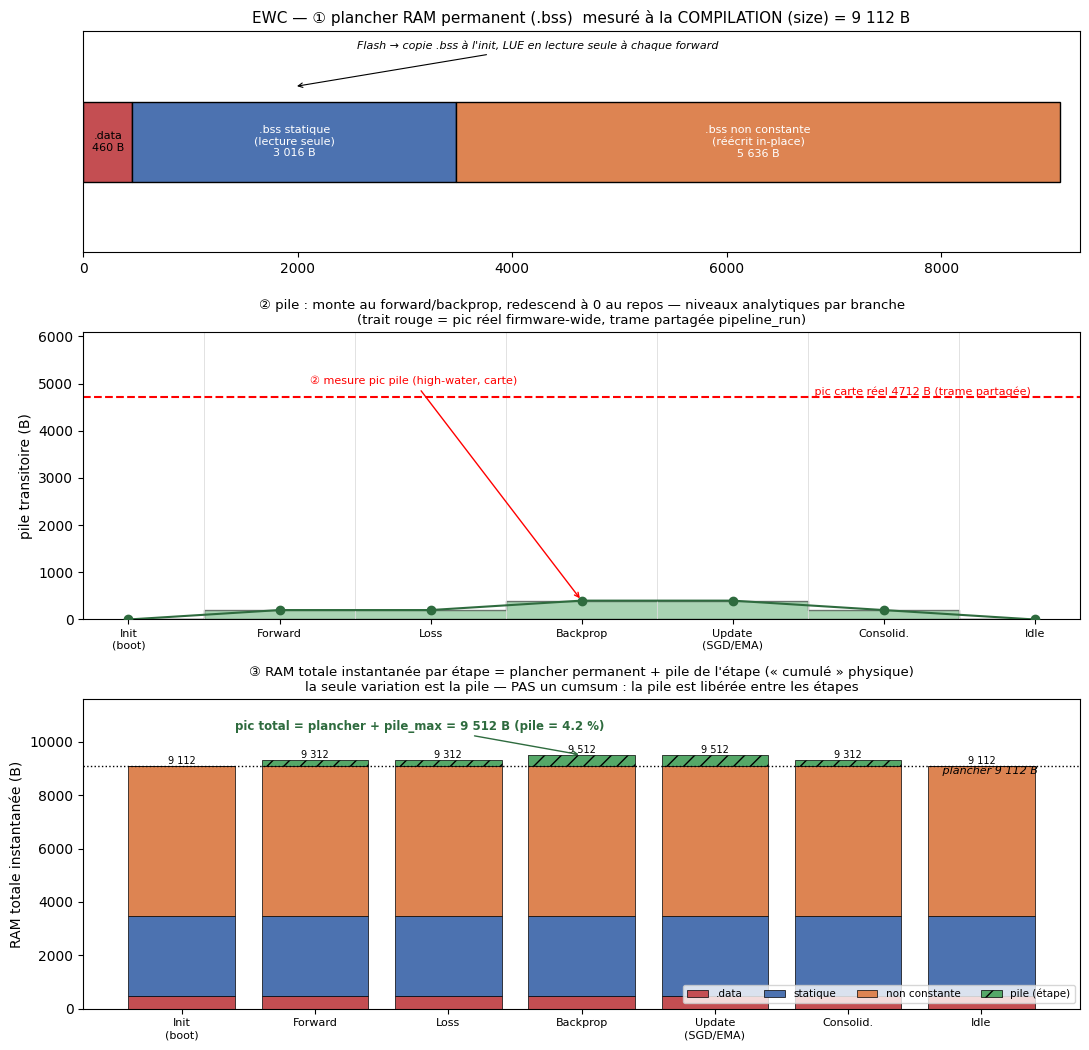

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_lifecycle_ewc.png


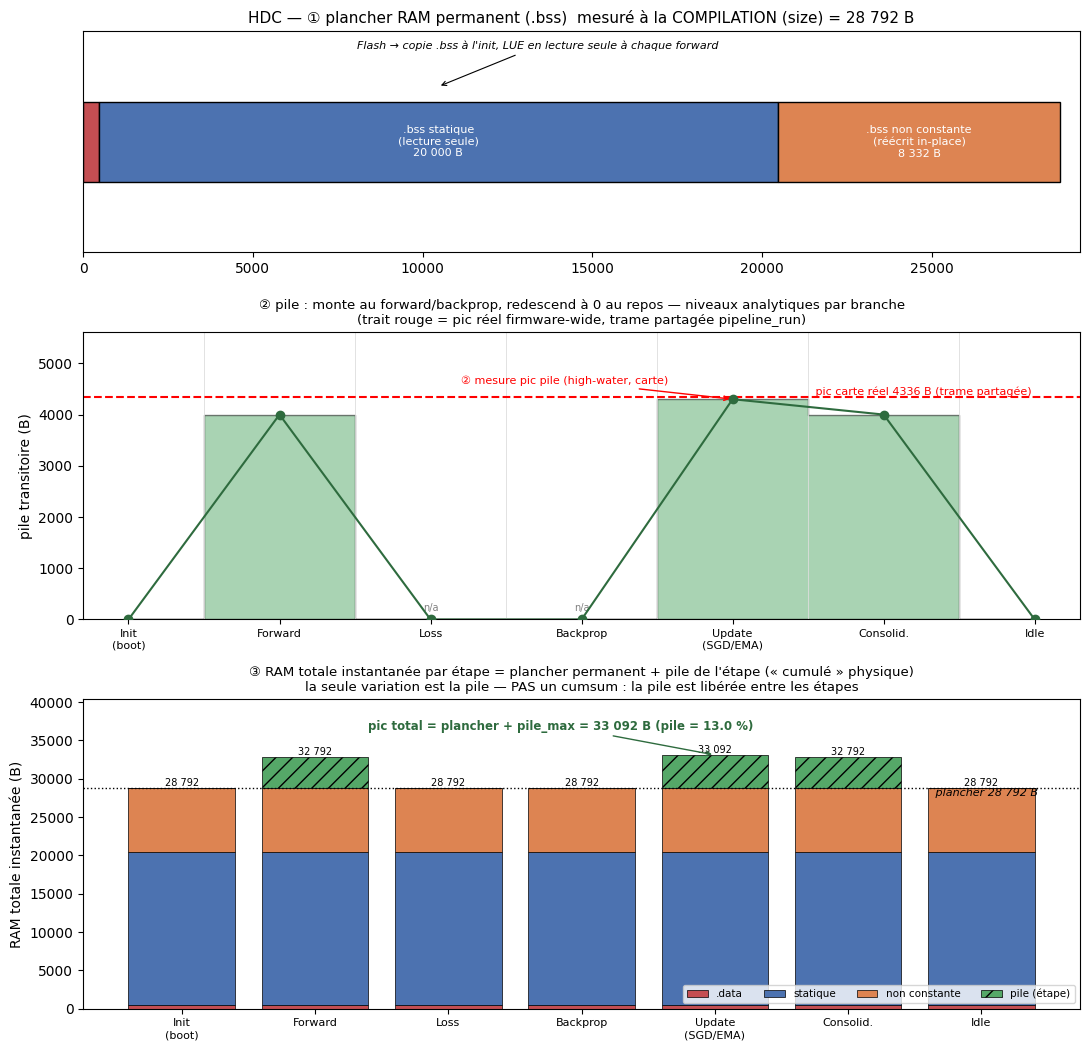

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_lifecycle_hdc.png


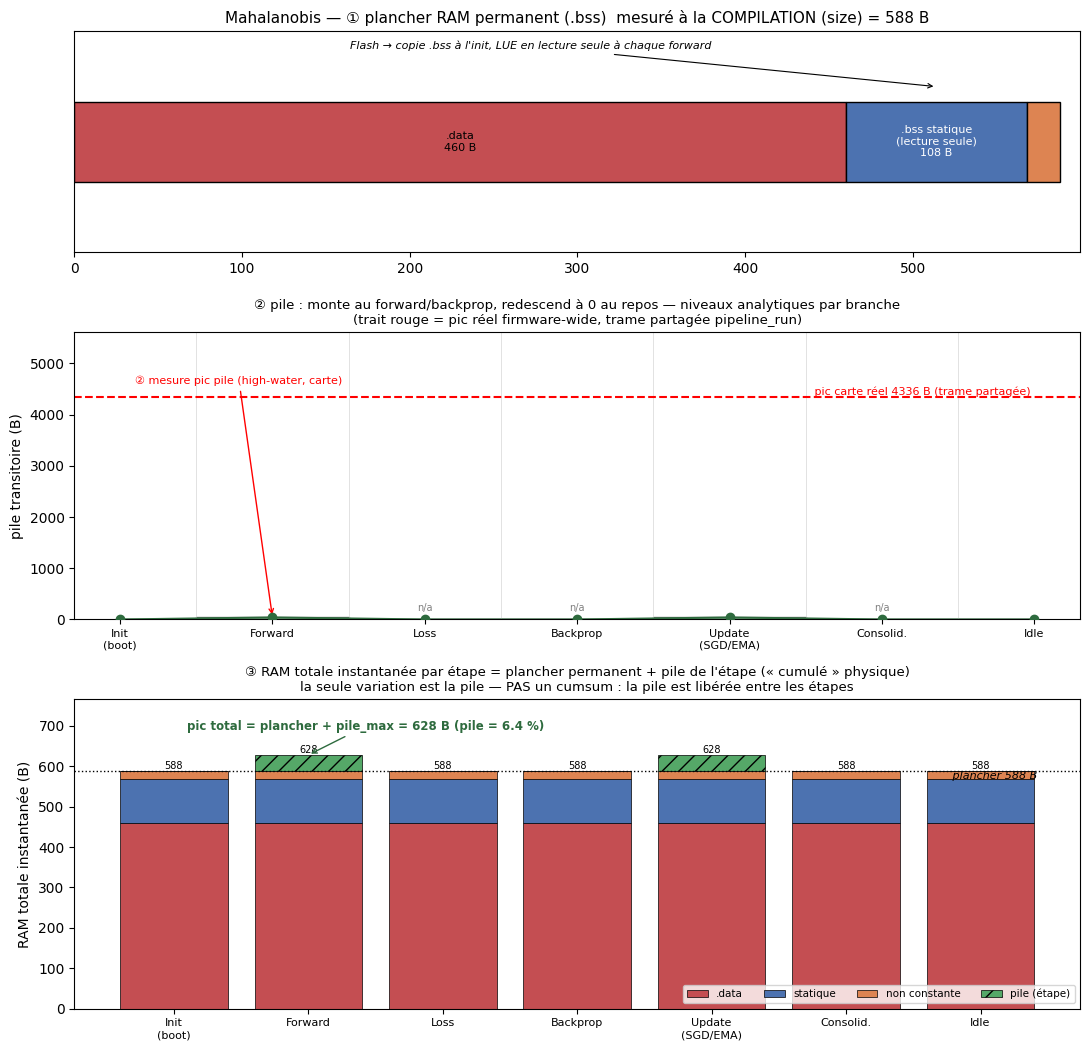

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_lifecycle_maha.png


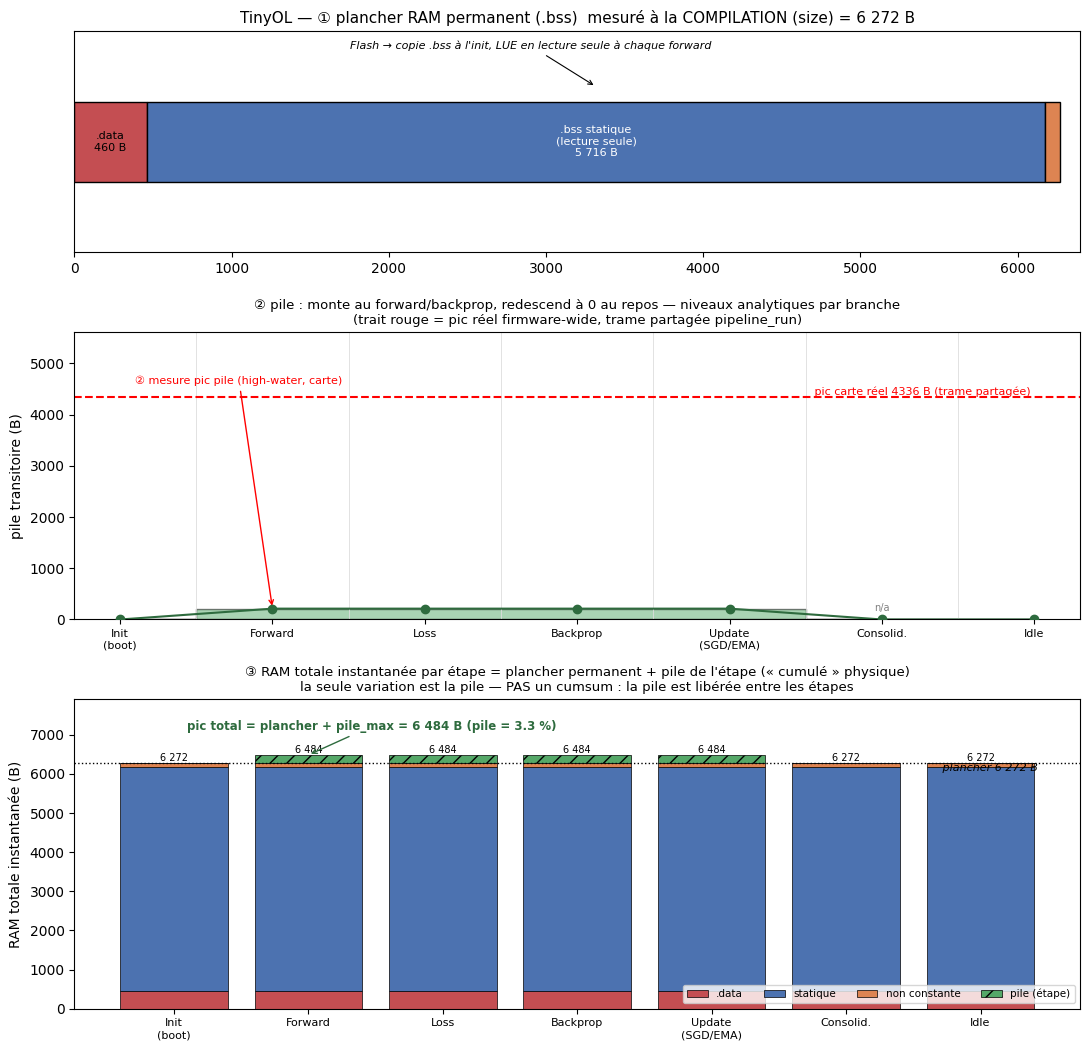

→ /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_lifecycle_tinyol.png


In [13]:
# ── Schéma 7 : cycle de vie mémoire par modèle (étapes + courbe de pile) ────
LIFECYCLE_STEPS = ["Init\n(boot)", "Forward", "Loss", "Backprop",
                   "Update\n(SGD/EMA)", "Consolid.", "Idle"]
# Quelles étapes existent réellement selon le modèle (les autres = grisées « n/a »).
MODEL_STEPS = {
    "EWC":         {"Loss": True,  "Backprop": True,  "Consolid.": True},
    "HDC":         {"Loss": False, "Backprop": False, "Consolid.": True},
    "Mahalanobis": {"Loss": False, "Backprop": False, "Consolid.": False},
    "TinyOL":      {"Loss": True,  "Backprop": True,  "Consolid.": False},
}

def lifecycle_diagram(model, board_peak=None):
    """Schéma hybride : plancher .bss (haut) + pile par étape (milieu)
    + RAM totale instantanée = plancher + pile empilés (bas, « cumulé » physique)."""
    m = bd[model]; act = MODEL_STEPS[model]
    si, st = m["stack_infer"], m["stack_train"]
    lvl = {"Init\n(boot)": 0, "Forward": si,
           "Loss": si if act.get("Loss", True) else 0,
           "Backprop": st if act.get("Backprop", True) else 0,
           "Update\n(SGD/EMA)": st,
           "Consolid.": si if act.get("Consolid.", True) else 0, "Idle": 0}

    fig, (axT, axB, axC) = plt.subplots(3, 1, figsize=(11, 10.6),
                                        gridspec_kw={"height_ratios": [1, 1.3, 1.4]})
    # ── Panneau HAUT : plancher permanent (.bss) mesuré à la COMPILATION ──
    segs = [(".data", DATA, C_DATA),
            (".bss statique\n(lecture seule)", m["static"], C_STATIC),
            (".bss non constante\n(réécrit in-place)", m["modular"], C_MODULAR)]
    tot = DATA + m["static"] + m["modular"]; left = 0
    for lab, val, col in segs:
        axT.barh(0, val, left=left, color=col, edgecolor="black")
        if val > tot * 0.05:
            axT.text(left + val / 2, 0, f"{lab}\n{val:,} B".replace(",", " "),
                     ha="center", va="center", fontsize=8,
                     color="white" if col != C_DATA else "black")
        left += val
    axT.set_xlim(0, tot * 1.02); axT.set_ylim(-1.1, 1.1); axT.set_yticks([])
    axT.set_title(f"{model} — ① plancher RAM permanent (.bss), mesuré à la COMPILATION "
                  f"(size) = {tot:,} B".replace(",", " "), fontsize=11)
    axT.annotate("Flash → copie .bss à l'init, LUE en lecture seule à chaque forward",
                 xy=(m["static"] * 0.5 + DATA, 0.55), xytext=(tot * 0.28, 0.92),
                 fontsize=8, style="italic", arrowprops=dict(arrowstyle="->", lw=0.8))
    # ── Panneau MILIEU : pile transitoire au fil des étapes ──
    xs = np.arange(len(LIFECYCLE_STEPS)); ys = [lvl[s] for s in LIFECYCLE_STEPS]
    ymax = max(st, board_peak or 0) * 1.28 + 60
    axB.fill_between(xs, ys, step="mid", color=C_STACK, alpha=.5, edgecolor="black")
    axB.plot(xs, ys, "-o", color="#2E6B3E", zorder=4)
    for i, s in enumerate(LIFECYCLE_STEPS):
        if ys[i] == 0 and s not in ("Init\n(boot)", "Idle"):
            axB.text(i, ymax * 0.03, "n/a", ha="center", fontsize=7, color="grey")
    for i in range(len(xs) - 1):
        axB.axvline(i + 0.5, color="#DDD", lw=0.6)
    imax = int(np.argmax(ys))
    axB.annotate("② mesure pic pile (high-water, carte)", xy=(imax, ys[imax]),
                 xytext=(max(imax - 1.8, 0.1), ymax * 0.82), fontsize=8, color="red",
                 arrowprops=dict(arrowstyle="->", color="red"))
    if board_peak:
        axB.axhline(board_peak, color="red", ls="--", lw=1.5)
        axB.text(len(xs) - 1, board_peak,
                 f" pic carte réel {board_peak} B (trame partagée) ",
                 ha="right", va="bottom", fontsize=8, color="red")
    axB.set_xticks(xs); axB.set_xticklabels(LIFECYCLE_STEPS, fontsize=8)
    axB.set_ylabel("pile transitoire (B)"); axB.set_ylim(0, ymax)
    axB.set_title("② pile : monte au forward/backprop, redescend à 0 au repos — "
                  "niveaux analytiques par branche\n(trait rouge = pic réel firmware-wide, "
                  "trame partagée pipeline_run)", fontsize=9.5)
    # ── Panneau BAS : ③ RAM totale instantanée = plancher + pile empilés ──
    # « Cumulé » physique : composantes empilées À UN INSTANT DONNÉ. PAS un cumsum
    # étape par étape : la pile est libérée entre les étapes, un cumsum compterait
    # plusieurs fois de la mémoire déjà rendue (aucun octet réel ne correspondrait).
    floor_segs = [(".data", DATA, C_DATA), ("statique", m["static"], C_STATIC),
                  ("non constante", m["modular"], C_MODULAR)]
    bottom = np.zeros(len(xs))
    for lab, val, col in floor_segs:
        axC.bar(xs, val, bottom=bottom, color=col, edgecolor="black", lw=0.5, label=lab)
        bottom += val
    axC.bar(xs, ys, bottom=bottom, color=C_STACK, edgecolor="black", lw=0.5,
            hatch="//", label="pile (étape)")
    peak_tot = tot + ys[imax]
    for i in range(len(xs)):
        t = tot + ys[i]
        axC.text(i, t, f"{t:,}".replace(",", " "), ha="center", va="bottom", fontsize=7)
    axC.axhline(tot, color="black", ls=":", lw=1)
    axC.text(len(xs) - 0.55, tot, f" plancher {tot:,} B ".replace(",", " "),
             ha="right", va="top", fontsize=8, style="italic")
    axC.annotate(f"pic total = plancher + pile_max = {peak_tot:,} B "
                 f"(pile = {100 * ys[imax] / peak_tot:.1f} %)".replace(",", " "),
                 xy=(imax, peak_tot), xytext=(max(imax - 2.6, 0.1), peak_tot * 1.10),
                 fontsize=8.5, color="#2E6B3E", weight="bold",
                 arrowprops=dict(arrowstyle="->", color="#2E6B3E"))
    axC.set_xticks(xs); axC.set_xticklabels(LIFECYCLE_STEPS, fontsize=8)
    axC.set_ylabel("RAM totale instantanée (B)"); axC.set_ylim(0, peak_tot * 1.22)
    axC.legend(fontsize=7.5, ncol=4, loc="lower right")
    axC.set_title("③ RAM totale instantanée par étape = plancher permanent + pile de l'étape "
                  "(« cumulé » physique)\nla seule variation est la pile — "
                  "PAS un cumsum : la pile est libérée entre les étapes", fontsize=9.5)
    plt.tight_layout()
    key = model.lower().replace("mahalanobis", "maha")
    plt.savefig(FIGDIR / f"fig_lifecycle_{key}.png", dpi=300, bbox_inches="tight")
    plt.show(); print("→", FIGDIR / f"fig_lifecycle_{key}.png")

for _mdl in ["EWC", "HDC", "Mahalanobis", "TinyOL"]:
    lifecycle_diagram(_mdl, board.get(_mdl, {}).get("stack_peak_bytes"))

## 7. Comparaison des 3 cas mesurés (carte réelle)

Trois builds mesurés sur NUCLEO-F439ZI (`experiments/exp_S39_ram/`) : **5-feat** (référence),
**INT8** (même firmware, flag 0x40), **all CMAPSS k=21** (rebuild dims ×4). Objectif : montrer
que le **pic de pile reste ~4,3–4,7 Ko** malgré un `.bss` qui passe de 105 à 185 Ko, et que la
**borne statique reste ≥ pic** sur chaque build (recalculée depuis les `.su` du build courant).

Comparaison des 3 cas mesurés (NUCLEO-F439ZI réelle) :

              .bss (B)  pic pile (B)  borne stat (B)  borne>=pic  RAM pic (B)  % 256Ko
cas                                                                                   
5feat EWC       105036          4712            4768        True       110208     42.0
5feat HDC       105036          4336            4768        True       109832     41.9
5feat Maha      105036          4336            4768        True       109832     41.9
5feat TinyOL    105036          4336            4768        True       109832     41.9
INT8 EWC        105036          4720            4768        True       110216     42.0
k=21 HDC        184864          4392            4800        True       189716     72.4
k=21 EWC        184864          4728            4800        True       190052     72.5


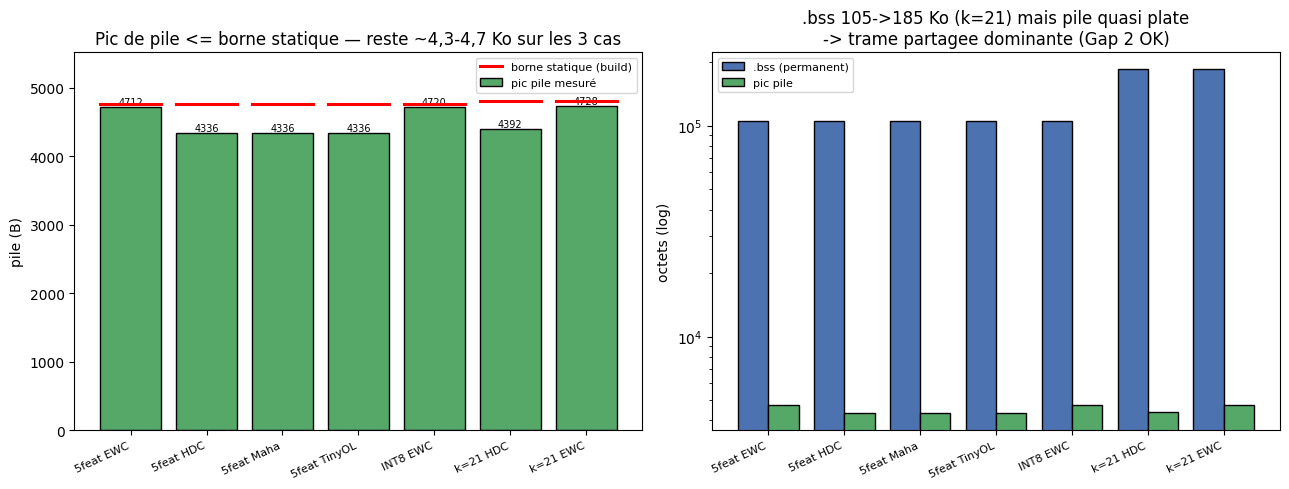

-> /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ram_measurement/fig_cases_compare.png


In [14]:
# ── Schéma 8 : comparaison des 3 cas mesurés (5feat / INT8 / all k=21) ──────
def _load_case(fname):
    f = ROOT / "experiments" / "exp_S39_ram" / fname
    return json.loads(f.read_text()) if f.exists() else None

CASES = [
    ("5feat EWC", "ram_ewc.json"), ("5feat HDC", "ram_hdc.json"),
    ("5feat Maha", "ram_mahalanobis.json"), ("5feat TinyOL", "ram_tinyol.json"),
    ("INT8 EWC", "ram_ewc-int8_int8.json"),
    ("k=21 HDC", "ram_hdc_all_k21.json"), ("k=21 EWC", "ram_ewc_all_k21.json"),
]
rows = []
for lab, fn in CASES:
    d = _load_case(fn)
    if not d:
        print(f"[!] {lab} : {fn} absent -> « à mesurer » (non tracé)")
        continue
    rows.append({
        "cas": lab, ".bss (B)": d["bss_bytes"], "pic pile (B)": d["stack_peak_bytes"],
        "borne stat (B)": d.get("static_bound_bytes"),
        "borne>=pic": d.get("bound_ge_measured"),
        "RAM pic (B)": d["ram_peak_bytes"],
        "% 256Ko": round(100 * d["ram_peak_bytes"] / RAM_TOTAL, 1),
    })
dfc = pd.DataFrame(rows).set_index("cas")
print("Comparaison des 3 cas mesurés (NUCLEO-F439ZI réelle) :\n")
print(dfc.to_string())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1]})
labels = [r["cas"] for r in rows]
peaks = [r["pic pile (B)"] for r in rows]
bounds = [r["borne stat (B)"] for r in rows]
bss = [r[".bss (B)"] for r in rows]
xx = np.arange(len(labels))
# (gauche) pic pile vs borne statique — reste borné et ~constant
axL.bar(xx, peaks, color=C_STACK, edgecolor="black", label="pic pile mesuré")
for i, b in enumerate(bounds):
    if b:
        axL.plot([i - 0.4, i + 0.4], [b, b], color="red", lw=2.2, zorder=5)
    axL.text(i, peaks[i], f"{peaks[i]}", ha="center", va="bottom", fontsize=7)
axL.plot([], [], color="red", lw=2.2, label="borne statique (build)")
axL.set_xticks(xx); axL.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
axL.set_ylabel("pile (B)"); axL.set_ylim(0, max(bounds) * 1.15)
axL.set_title("Pic de pile <= borne statique — reste ~4,3-4,7 Ko sur les 3 cas")
axL.legend(fontsize=8)
# (droite) .bss explose mais pile ~plate → thèse « trame partagée »
axR.bar(xx - 0.2, bss, 0.4, color=C_STATIC, edgecolor="black", label=".bss (permanent)")
axR.bar(xx + 0.2, peaks, 0.4, color=C_STACK, edgecolor="black", label="pic pile")
axR.set_yscale("log"); axR.set_xticks(xx)
axR.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
axR.set_ylabel("octets (log)")
axR.set_title(".bss 105->185 Ko (k=21) mais pile quasi plate\n-> trame partagee dominante (Gap 2 OK)")
axR.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGDIR / "fig_cases_compare.png", dpi=300, bbox_inches="tight")
plt.show(); print("->", FIGDIR / "fig_cases_compare.png")